In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import seaborn as sns

In [3]:
G = nx.karate_club_graph()

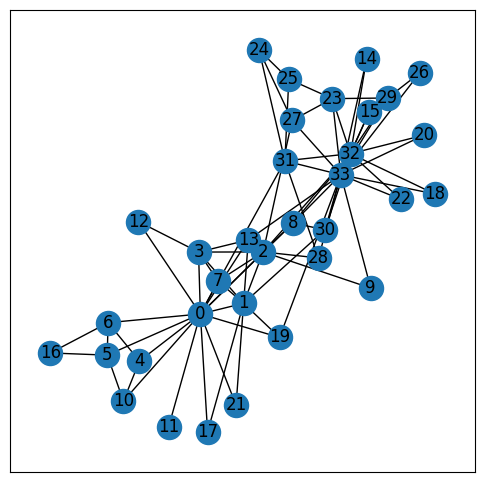

In [5]:
pos = nx.spring_layout(G,seed = 2)
plt.figure(figsize = (6,6))
nx.draw_networkx(G,pos = pos)

In [7]:
A = nx.adjacency_matrix(G).toarray()

<Axes: >

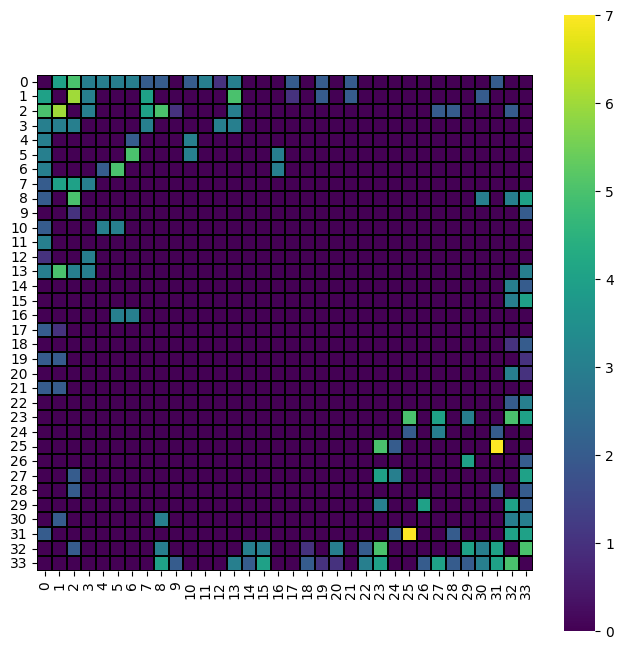

In [9]:
plt.figure(figsize = (8,8))
sns.heatmap(A,cmap = 'viridis',square = True,
            cbar = True,linecolor = 'k',
            linewidths = 0.1)

In [11]:
degrees = np.sum(A,axis = 1)
degrees

array([42, 29, 33, 18,  8, 14, 13, 13, 17,  3,  8,  3,  4, 17,  5,  7,  6,
        3,  3,  5,  4,  4,  5, 21,  7, 14,  6, 13,  6, 13, 11, 21, 38, 48])

In [13]:
D = np.diag(degrees)

<Axes: >

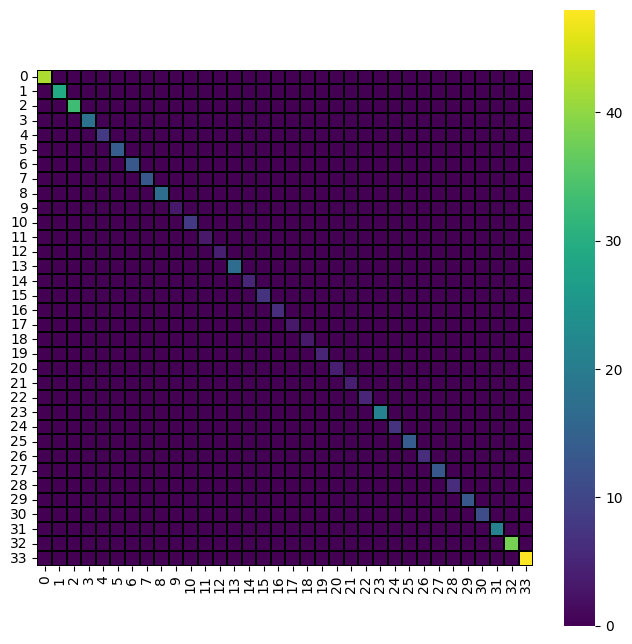

In [15]:
plt.figure(figsize = (8,8))
sns.heatmap(D,cmap = 'viridis',
            square = True,cbar = True,
            linecolor = 'k',linewidth = 0.1)

In [17]:
#reverse表示按照从大到小排序(降序),因为默认是升序
#.degree返回节点名和度数,因为知道是无向图,返回的索引行列等价
degree_sequence = sorted((d for n,d in G.degree()),reverse = True)#排序可迭代对象,是python内置函数

#返回度数中的最大值
dmax = max(degree_sequence)
dict_degree = dict(G.degree)#

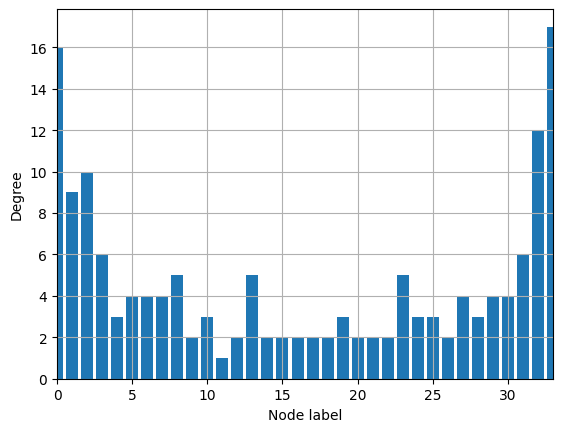

In [23]:
plt.bar(dict_degree.keys(),dict_degree.values())
plt.xlabel('Node label')
plt.ylabel('Degree')
plt.xlim(0,33)
plt.grid(True)

In [33]:
def filter_value(dict_,unique):
    newDict = {}
    for (key,value) in dict_.items():
        if value == unique:
            newDict[key] = value

    return newDict

/opt/anaconda3/lib/python3.12/site-packages/networkx/drawing/nx_pylab.py:450: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  node_collection = ax.scatter(


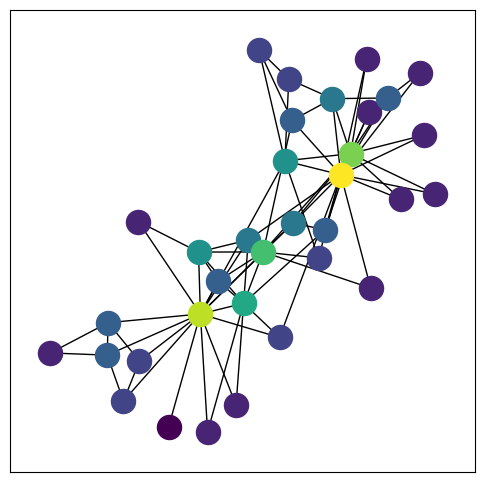

In [35]:
unique_deg = set(degree_sequence)#配置成无重复元素的数组
colors = plt.cm.viridis(np.linspace(0,1,len(unique_deg)))

plt.figure(figsize = (6,6))
nx.draw_networkx_edges(G,pos)#绘制图的边

for deg_i,color_i in zip(unique_deg,colors):
    
    dict_i = filter_value(dict_degree,deg_i)
    nx.draw_networkx_nodes(G,pos,nodelist = list(dict_i.keys()),node_color = color_i)

In [38]:
L = D-A

<Axes: >

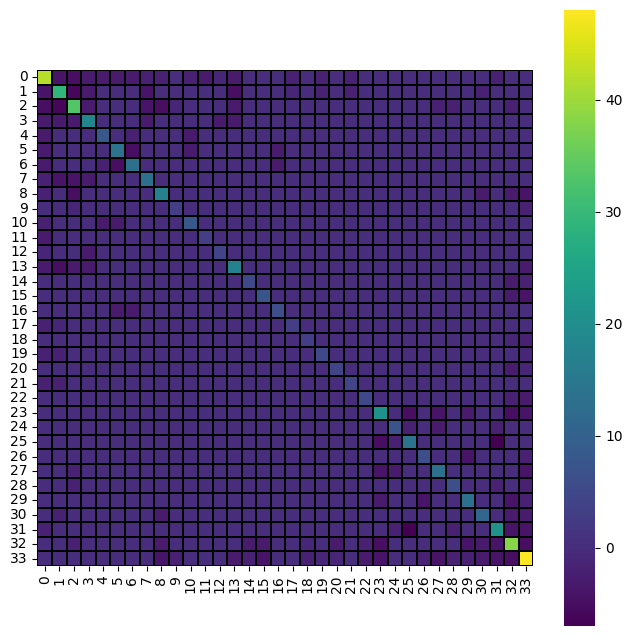

In [40]:
plt.figure(figsize = (8,8))
sns.heatmap(L,cmap = 'viridis',square = True,cbar = True,
            linecolor = 'k',linewidths = 0.1)

In [42]:
D_inv_sqrt = np.diag(1.0/np.sqrt(degrees))

In [44]:
L_norm = D_inv_sqrt @ L @ D_inv_sqrt

<Axes: >

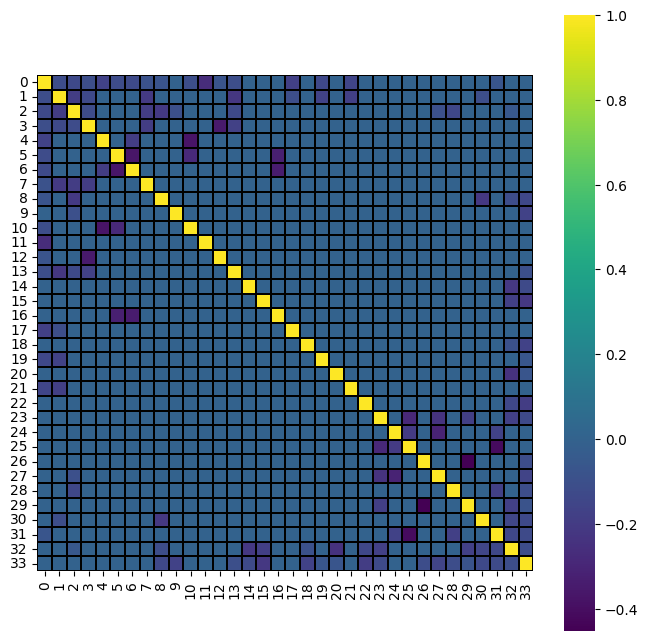

In [46]:
plt.figure(figsize = (8,8))
sns.heatmap(L_norm,cmap = 'viridis',square = True,cbar = True,
            linecolor = 'k',linewidths = 0.1)

In [52]:
lambdas,V = np.linalg.eig(L_norm)

In [56]:
lambdas_sorted = np.sort(lambdas)#排序Numpy数组(类似sorted,但是是针对numpy的),默认升序
V_sorted = V[:,lambdas.argsort()]#返回排序后的索引,默认升序

<Axes: >

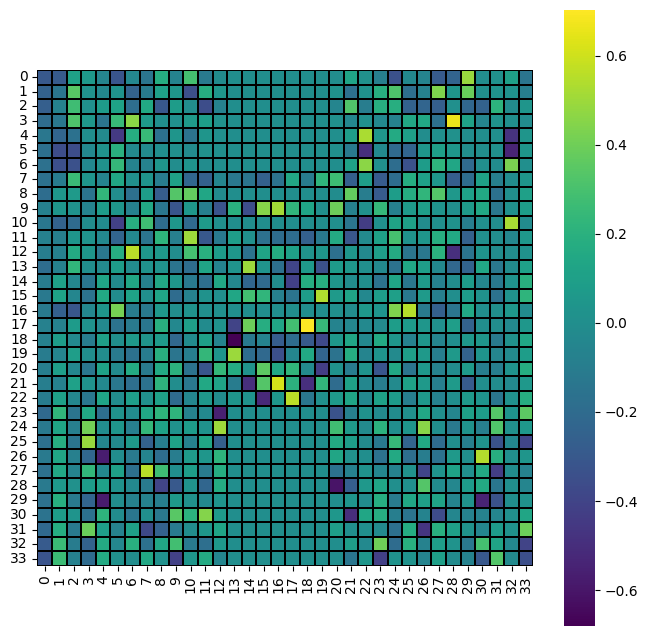

In [60]:
plt.figure(figsize = (8,8))
sns.heatmap(V_sorted,cmap = 'viridis',
            square = True,linecolor = 'k',linewidths = 0.1)

<Axes: >

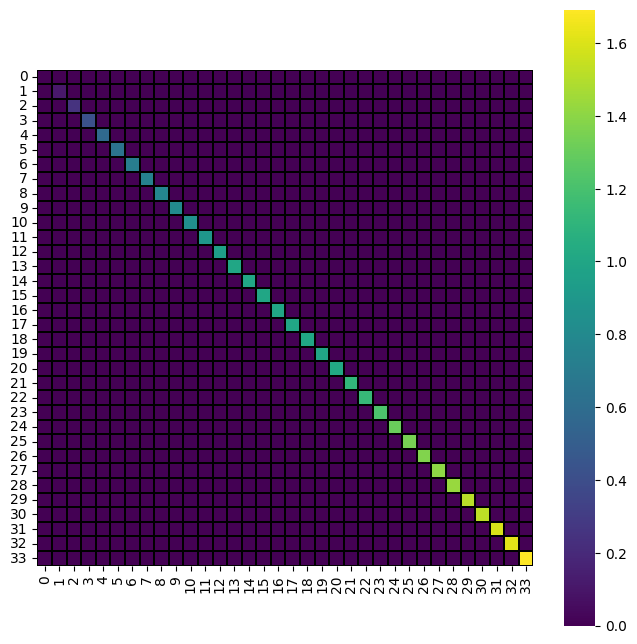

In [62]:
plt.figure(figsize = (8,8))
sns.heatmap(np.diag(lambdas_sorted),cmap = 'viridis',
            square = True,linecolor = 'k',linewidths = 0.1)

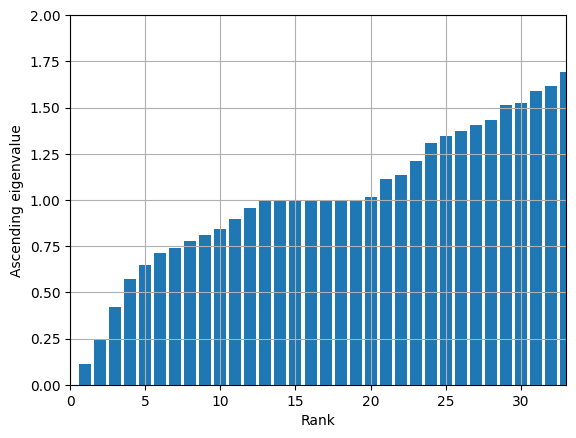

In [66]:
plt.bar(dict_degree.keys(),lambdas_sorted)
plt.ylabel('Ascending eigenvalue')
plt.xlabel('Rank')
plt.xlim(0,33)
plt.ylim(0,2)
plt.grid(True)

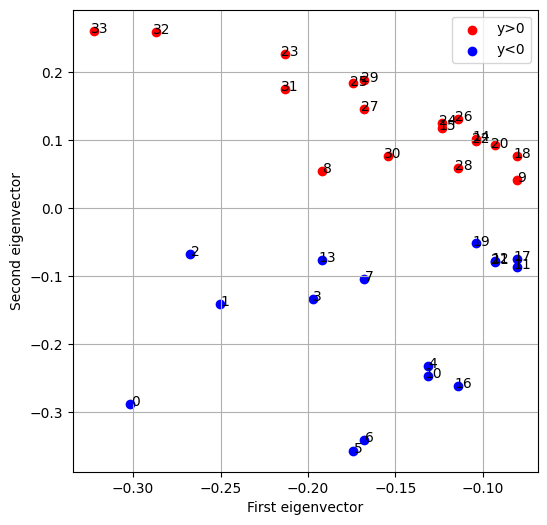

In [82]:
plt.figure(figsize = (6,6))

#根据第二个特征轴上
positive_idx = V_sorted[:,1] > 0#
negative_idx = V_sorted[:,1] < 0

plt.scatter(V_sorted[positive_idx,0],V_sorted[positive_idx,1],
            color = 'red',label = 'y>0')

plt.scatter(V_sorted[negative_idx,0],V_sorted[negative_idx,1],
            color = 'blue',label = 'y<0')

for i in range(V_sorted.shape[0]):
    plt.text(V_sorted[i,0]+0.003,V_sorted[i,1]+0.003,#文本稍微偏移一些
             str(i),
             fontsize = 10,
             ha = 'center',va = 'center')#水平居中和处置居中(控制文字对其方式)

plt.grid(True)
plt.xlabel('First eigenvector')
plt.ylabel('Second eigenvector')
plt.legend()#显示图里

In [88]:
colors = ['r' for i in range(0,34)]
for i in range(0,34):
    if (V_sorted[i,1] <0):
        colors[i] = 'b'

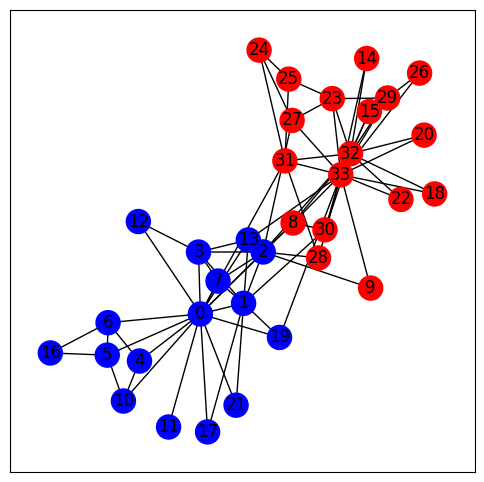

In [90]:
plt.figure(figsize = (6,6))
nx.draw_networkx(G,pos,node_color = colors)